<a href="https://colab.research.google.com/github/Max48732/-/blob/main/CodeLab4_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Технологии обработки больших данных

Занятие 4. Работа с SQL запросами в PySpark

1. Запуск PySpark на локальной машине
2. TempView - представления DataFrame
3. Базовый синтаксис SQL
4. Домашнее задание
  
**Рекомендованная литература:** Б.Форта. SQL за 10 минут (Можно найти на гугл [диске](https://drive.google.com/drive/folders/14igaMTWTQvEszOYKfnVkjc8A0bpXLx3e?usp=sharing)).

![](img/spark_libs.png)

### 1. Запуск PySpark на локальной машине

# Запускайте в изолированой среде venv / conda env

! pip install pyspark

In [2]:
import pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

### 2. View - представления DataFrame

**Columns**  

Age - возраст (numeric)  
Sex - пол (text: male, female)  
Job - уровень рабочей квалификации (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)  
Housing - жилье (text: own, rent, or free)  
Saving accounts - накопления (text - little, moderate, quite rich, rich)  
Checking account - средние траты (numeric, in DM - Deutsch Mark)  
Credit amount - размер кредита (numeric, in DM)  
Duration - срок кредита (numeric, in month)  
Purpose - цель кредита (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)

In [ ]:
DATA_PATH = 'sample_data/credit_data.csv'

SCHEMA = "id INT, Age INT, Sex STRING, Job INT, Housing STRING, Saving_accounts STRING, \
Checking_account STRING, Credit_amount INT, Duration INT, Purpose STRING"

df = spark.read.csv(DATA_PATH, schema=SCHEMA, header=True)
type(df)

In [ ]:
df.createOrReplaceTempView("credit_table")

С помощью запросов SQL можно создавать новые представления DataFrame

In [ ]:
sub_df = spark.sql("SELECT id, Age, Sex FROM credit_table ")
sub_df.show(10)

### 3. Базовый синтаксис SQL

#### Извлечение отдельных столбцов

In [ ]:
spark.sql("SELECT Age FROM credit_table ").show(5)

#### Извлечение всех столбцов

In [ ]:
spark.sql("SELECT * FROM credit_table ").show(5)

#### Извлечение уникальных строк

In [ ]:
spark.sql("SELECT DISTINCT Purpose FROM credit_table ").show()

#### Ограничение результатов запроса

In [ ]:
spark.sql("SELECT * FROM credit_table LIMIT 5").show()

### Сортировка по строкам таблицы

In [ ]:
spark.sql("SELECT * FROM credit_table ORDER BY Duration").show(10)

In [ ]:
# Few columns sorting
spark.sql("SELECT * FROM credit_table ORDER BY Duration, Credit_amount").show(10)

#### Сортировка с указанием номера столбца

In [ ]:
spark.sql("SELECT * FROM credit_table ORDER BY 2, 3").show()

####  Направления сортировки - *DESC*

In [ ]:
spark.sql("SELECT * FROM credit_table ORDER BY Duration DESC").show(10)

In [ ]:
spark.sql("SELECT * FROM credit_table ORDER BY Credit_amount DESC, Duration ").show(10)

### Фильтрация данных

#### Оператор WHERE

In [ ]:
spark.sql("SELECT * FROM credit_table WHERE Purpose = 'car' ").show(10)

#### Операторы WHERE  

In [ ]:
#  =  Равенство
#  <> Неравенство
#  != Неравенство
#  <  Меньше
#  <= Меньше или равно
#  !< Не меньше
#  >  Больше
#  >= Больше или равно
#  !> Не больше
#  BETWEEN Вхождение в диапазон
#  IS NULL Значение NULL

In [ ]:
spark.sql("SELECT * FROM credit_table WHERE Housing != 'free' ").show(10)

In [ ]:
spark.sql("SELECT * FROM credit_table WHERE Credit_amount BETWEEN 1000 AND 2000 ").show(10)

### Расширенная фильтрация данных

#### Комбинирование условий WHERE

In [ ]:
spark.sql("""SELECT * FROM credit_table
                WHERE Credit_amount > 10000
                  AND Purpose = 'car'
                ORDER BY Credit_amount
                """).show(10)

#### Условие OR

In [ ]:
spark.sql("""SELECT * FROM credit_table
                WHERE Purpose = 'furniture/equipment'
                   OR Purpose = 'business'
                ORDER BY Credit_amount
                """).show(10)

####  Условие вхождения в множество IN

In [ ]:
spark.sql("""SELECT * FROM credit_table
                WHERE Purpose IN ('furniture/equipment', 'business')
                ORDER BY Credit_amount
                """).show(10)

####  Условие NOT

In [ ]:
spark.sql("""SELECT * FROM credit_table
                WHERE Purpose IN ('furniture/equipment', 'business')
                  AND NOT Job = 0
                ORDER BY Credit_amount
                """).show(10)

### Фильтрация с использованием метасимволов

**Метасимволы** - Специальные символы, применяемые для поиска части значения.

**Шаблон поиска** - Условие отбора строк, состоящее из текста, метасимволов и любой их комбинации.


#### Оператор LIKE

Метасимвол **знак процента (%)** в шаблоне поиска означает найти все вхождения любого символа.  
Метасимвол **знак подчеркивания (_)** используется так же, как и знак %, но при этом учитывается не множество символов, а только один.  

In [ ]:
spark.sql("""SELECT DISTINCT Purpose FROM credit_table
                WHERE Purpose LIKE '%/%'
                """).show(10)

In [ ]:
spark.sql("""SELECT * FROM credit_table
                WHERE Housing LIKE 'ow_'
                """).show(5)

### Создание вычисляемых полей

**Поле** по сути то же самое, что и столбец. В основном эти термины взаимозаменяемы, хотя столбцы таблиц обычно называют столбцами, а термин поле чаще применяется по отношению к вычисляемым полям.


In [ ]:
spark.sql("""SELECT id, Age, Sex, Purpose,
                    Credit_amount / Duration AS Month_payment
                    FROM credit_table
             """).show(5)

## 4. Домашнее задание

Решение должно быть с использованием SQL!

1. Сколько мужчин и женщин (признак Sex) представлено в этом наборе данных?

In [22]:
spark.sql("SELECT Sex, COUNT(*) AS count FROM credit_table GROUP BY Sex").show()

+------+-----+
|   Sex|count|
+------+-----+
|female| 2537|
|  male| 2463|
+------+-----+



2. Каков средний возраст (признак Age) женщин?

In [23]:
spark.sql("SELECT ROUND(AVG(Age), 2) as avg_age_female FROM credit_table WHERE Sex = 'female'").show()

+--------------+
|avg_age_female|
+--------------+
|         46.42|
+--------------+



3. Какова доля заемщиков с собственным жильем (признак Housing)?

In [24]:
spark.sql("SELECT ROUND(AVG(CASE WHEN Housing = 'own' THEN 1.0 ELSE 0.0 END) * 100, 2) as own_pct FROM credit_table").show()

+-------+
|own_pct|
+-------+
|  33.70|
+-------+



4. Каково среднее значение возраста тех, кто имеет высокие накопления (признак Saving_accounts)?

In [25]:
spark.sql("SELECT AVG(Age) as avg_age_high_savings FROM credit_table WHERE Saving_accounts IN ('rich', 'quite rich')").show()

+--------------------+
|avg_age_high_savings|
+--------------------+
|   46.88472906403941|
+--------------------+



5. Каково среднеквадратичное отклонения возраста тех, кто имеет высокие накопления (признак Saving_accounts)?

In [26]:
spark.sql("SELECT ROUND(STDDEV(Age), 2) as stddev_age_high_savings FROM credit_table WHERE Saving_accounts IN ('rich', 'quite rich')").show()

+-----------------------+
|stddev_age_high_savings|
+-----------------------+
|                  16.72|
+-----------------------+



6. Выведите гистограмму категорий покупок (признак Purpose) для мужчин и женщин.

In [27]:
spark.sql("""
    SELECT Sex, Purpose, COUNT(*) as frequency
    FROM credit_table
    GROUP BY Sex, Purpose
    ORDER BY Sex, Purpose
""").show(20)

+------+-------------------+---------+
|   Sex|            Purpose|frequency|
+------+-------------------+---------+
|female|           business|      341|
|female|                car|      325|
|female|domestic appliances|      312|
|female|          education|      306|
|female|furniture/equipment|      305|
|female|           radio/TV|      325|
|female|            repairs|      300|
|female|    vacation/others|      323|
|  male|           business|      323|
|  male|                car|      303|
|  male|domestic appliances|      307|
|  male|          education|      297|
|  male|furniture/equipment|      301|
|  male|           radio/TV|      309|
|  male|            repairs|      302|
|  male|    vacation/others|      321|
+------+-------------------+---------+



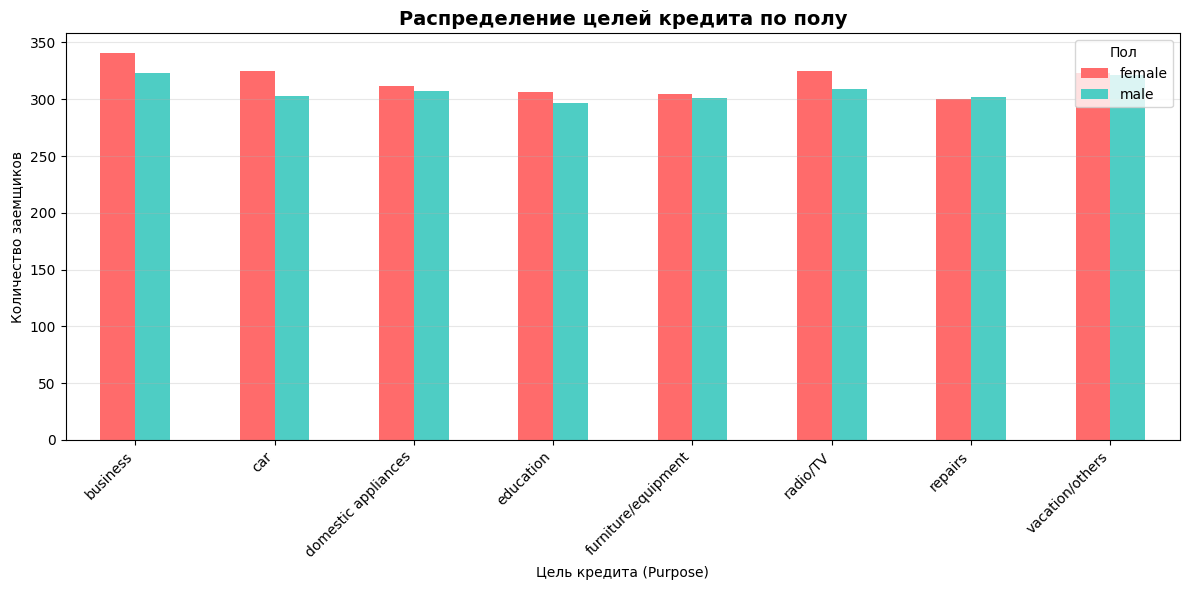

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

hist_data = spark.sql("""
    SELECT Sex, Purpose, COUNT(*) as frequency
    FROM credit_table
    GROUP BY Sex, Purpose
""").toPandas()

pivot = hist_data.pivot(index='Purpose', columns='Sex', values='frequency').fillna(0)

pivot.plot(kind='bar', figsize=(12, 6), color=['#ff6b6b', '#4ecdc4'])
plt.title('Распределение целей кредита по полу', fontsize=14, fontweight='bold')
plt.xlabel('Цель кредита (Purpose)')
plt.ylabel('Количество заемщиков')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Пол')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

7. На что чаще всего берутся длинные кредиты (более 24 мес)?

In [28]:
spark.sql("""
    SELECT Purpose, COUNT(*) as long_credits_cnt
    FROM credit_table
    WHERE Duration > 24
    GROUP BY Purpose
    ORDER BY long_credits_cnt DESC
    LIMIT 1
""").show()

+--------+----------------+
| Purpose|long_credits_cnt|
+--------+----------------+
|business|             464|
+--------+----------------+



8. Какой средний срок кредита (признак Duration) для заемщиков, имеющих высокие текущие траты (признак Checking_account)?

In [29]:
spark.sql("SELECT AVG(Duration) as avg_dur_rich FROM credit_table WHERE Checking_account = 'rich'").show()

+-----------------+
|     avg_dur_rich|
+-----------------+
|38.79888712241653|
+-----------------+



9. Какой средний срок кредита (признак Duration) для заемщиков, имеющих низкие текущие траты (признак Checking_account)?

In [30]:
spark.sql("SELECT AVG(Duration) as avg_dur_little FROM credit_table WHERE Checking_account = 'little'").show()

+-----------------+
|   avg_dur_little|
+-----------------+
|38.32550860719875|
+-----------------+



10. На какую цель взят самый дорогой кредит?

In [31]:
spark.sql("SELECT Purpose, Credit_amount FROM credit_table ORDER BY Credit_amount DESC LIMIT 1").show()

+-------+-------------+
|Purpose|Credit_amount|
+-------+-------------+
|repairs|        19997|
+-------+-------------+

